## **Variables correlation**

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [3]:
EEA = pd.read_csv('reduced_EEA_2023.csv')

In [4]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Engine_Capacity(cm3),Engine_Power(kW)
0,1175.0,129.0,petrol,999.0,70.0
1,1122.0,117.0,petrol,999.0,59.0
2,1588.0,126.0,diesel,1968.0,110.0
3,1516.0,124.0,diesel,1968.0,110.0
4,1349.0,126.0,petrol,1498.0,110.0


In [5]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75530 entries, 0 to 75529
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Mass_in_Running_Order(kg)  75530 non-null  float64
 1   CO2_Emissions_WLTP(g/km)   75530 non-null  float64
 2   Fuel_Type                  75530 non-null  object 
 3   Engine_Capacity(cm3)       75530 non-null  float64
 4   Engine_Power(kW)           75530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 2.9+ MB


So, we have 4 numerical values and one categorical

we should look at the distribution of our numerical features so we can know which scaler to apply

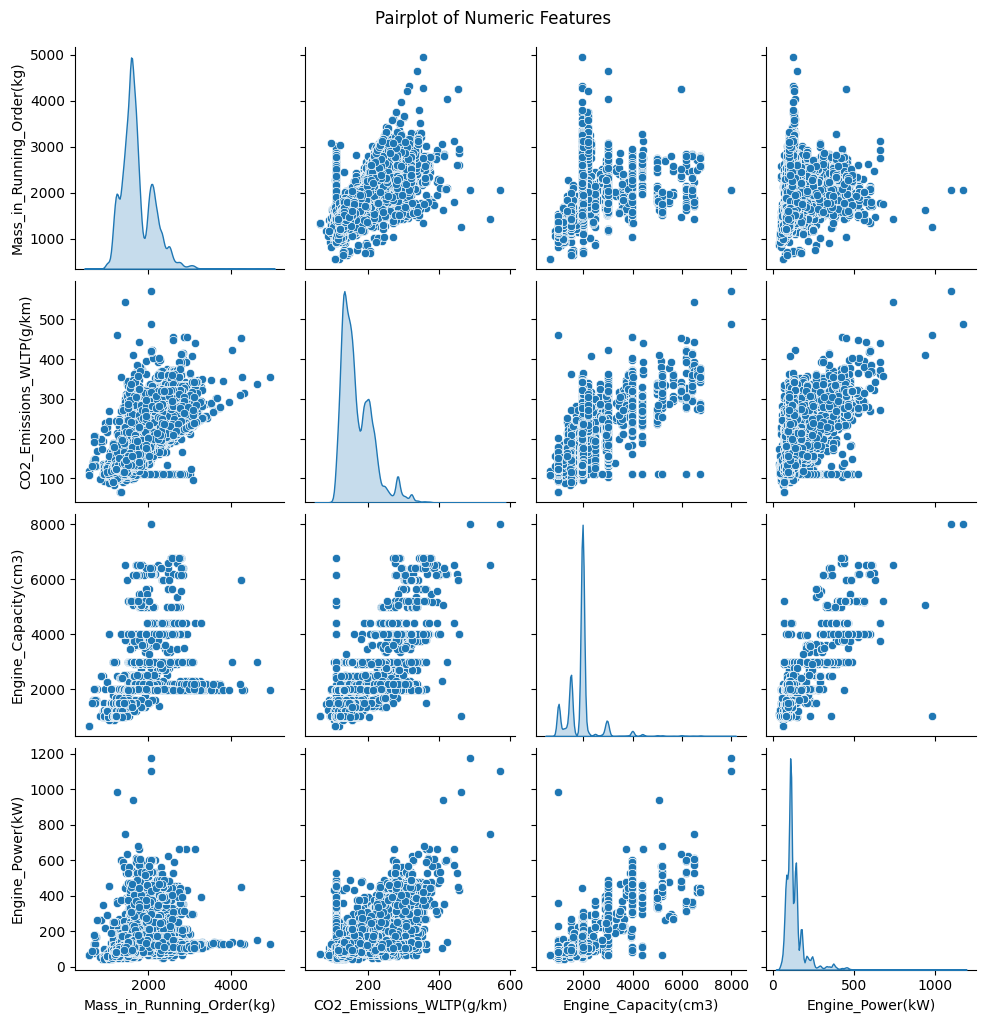

In [6]:
sns.pairplot(EEA, diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()


Mass:
 - Distribution: Right-skewed (positive skew)
 - Observations:
    - Clustered around 1000–2000 kg
    - Long tail to heavier vehicles (>2000 kg)
    - Likely outliers in the upper range

Engine capacity: 
  - Distribution: Right-skewed, but not heavily
  - Observations:
    - Looks like it has discrete bands. This is because vehicles share the exact same engine size due to the design norms, even though it’s a continuous variable
    - Clustering around typical engine sizes (1000, 1600, 2000, 3000 cm³)
    - Gaps between these clusters — not a smooth histogram

Engine_Power(kW):
  - Distribution: Heavily right skweed
  - Observations: 
    - Most vehicles are in the 50–150 kW range
    - Extreme outliers above 300–400 kW (likely high-performance cars)
    - These outliers will influence most models

 CO2_Emissions_WLTP(g/km):
  - Distribution: Also right-skewed
  - Observations:
    - Many vehicles emit between 100–200 g/km
    - Some go well above 250–300 g/km












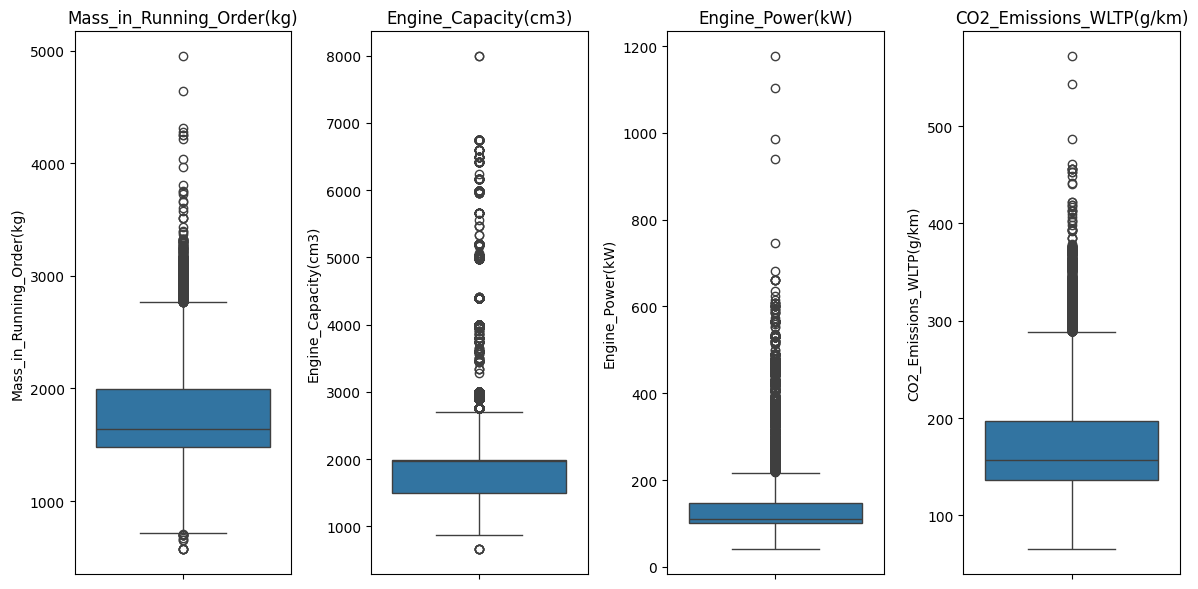

In [7]:

numeric_cols = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 
                'Engine_Power(kW)', 'CO2_Emissions_WLTP(g/km)']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=EEA[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

### What does the Fuel type distribution look like?

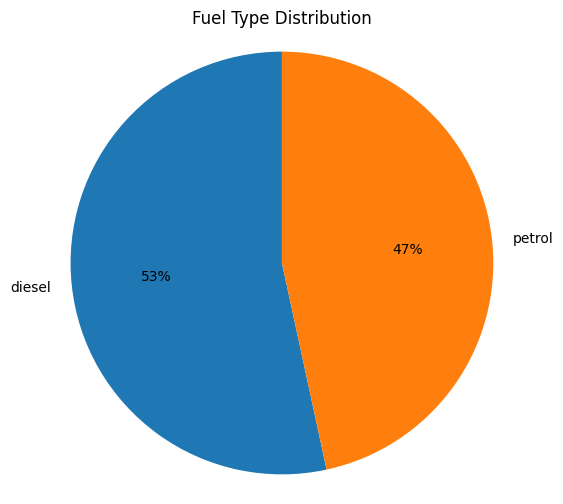

In [8]:

fuel_counts = EEA['Fuel_Type'].value_counts(normalize=True)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.0f%%', startangle=90)
plt.title('Fuel Type Distribution')
plt.axis('equal')  
plt.show()

Let's explore how our variables are explaining our target

## Categorical into dummies

In [9]:
EEA = pd.get_dummies(EEA, columns=['Fuel_Type'], drop_first=True)

In [10]:
EEA = EEA.astype(int)

In [11]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
0,1175,129,999,70,1
1,1122,117,999,59,1
2,1588,126,1968,110,0
3,1516,124,1968,110,0
4,1349,126,1498,110,1


In [12]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75530 entries, 0 to 75529
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Mass_in_Running_Order(kg)  75530 non-null  int64
 1   CO2_Emissions_WLTP(g/km)   75530 non-null  int64
 2   Engine_Capacity(cm3)       75530 non-null  int64
 3   Engine_Power(kW)           75530 non-null  int64
 4   Fuel_Type_petrol           75530 non-null  int64
dtypes: int64(5)
memory usage: 2.9 MB


## Model 1 - Linear Regression

In [14]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])



Train MSE (LR): 364.62
Test MSE (LR): 373.25
Train MAE (LR): 12.03
Test MAE (LR): 12.02
Train RMSE (LR): 19.10
Test RMSE (LR): 19.32
Train R² Score (LR): 0.816
Test R² Score (LR): 0.811


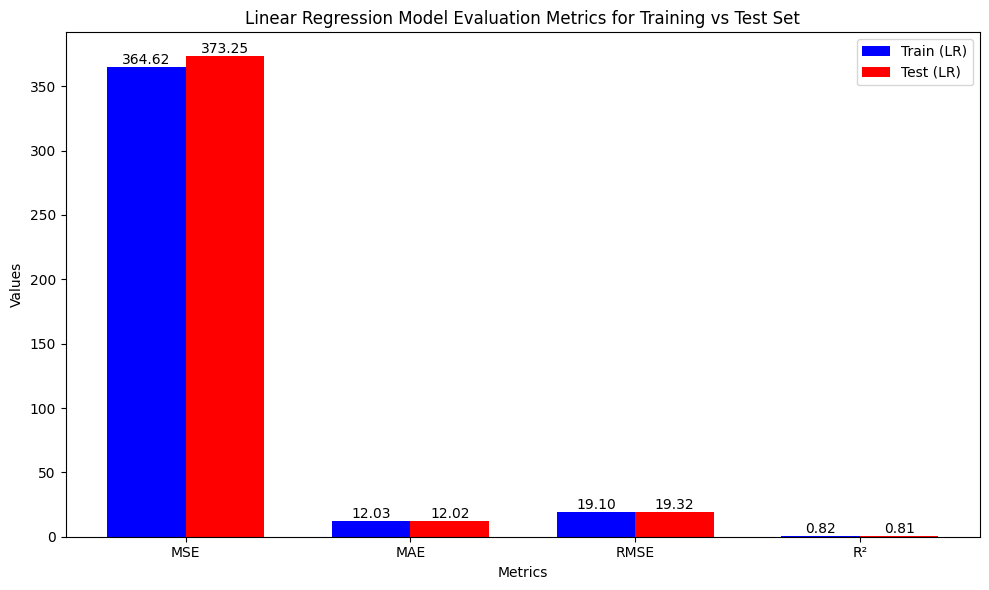

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model_scaled.predict(X_train_scaled)
y_test_pred_lr = lr_model_scaled.predict(X_test_scaled)

train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)

train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

train_mrse_lr = np.sqrt(train_mse_lr)
test_mrse_lr = np.sqrt(test_mse_lr)

train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print(f"Train MSE (LR): {train_mse_lr:.2f}")
print(f"Test MSE (LR): {test_mse_lr:.2f}")
print(f"Train MAE (LR): {train_mae_lr:.2f}")
print(f"Test MAE (LR): {test_mae_lr:.2f}")
print(f"Train RMSE (LR): {train_mrse_lr:.2f}")
print(f"Test RMSE (LR): {test_mrse_lr:.2f}")
print(f"Train R² Score (LR): {train_r2_lr:.3f}")
print(f"Test R² Score (LR): {test_r2_lr:.3f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values_lr = [train_mse_lr, train_mae_lr, train_mrse_lr, train_r2_lr]
test_values_lr = [test_mse_lr, test_mae_lr, test_mrse_lr, test_r2_lr]

bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values_lr, bar_width, label='Train (LR)', color='blue')
plt.bar(index + bar_width, test_values_lr, bar_width, label='Test (LR)', color='red')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Linear Regression Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

for i, value in enumerate(train_values_lr):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values_lr):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    37.240262
3           Fuel_Type_petrol    22.820005
2           Engine_Power(kW)    10.870419
1       Engine_Capacity(cm3)     0.912619


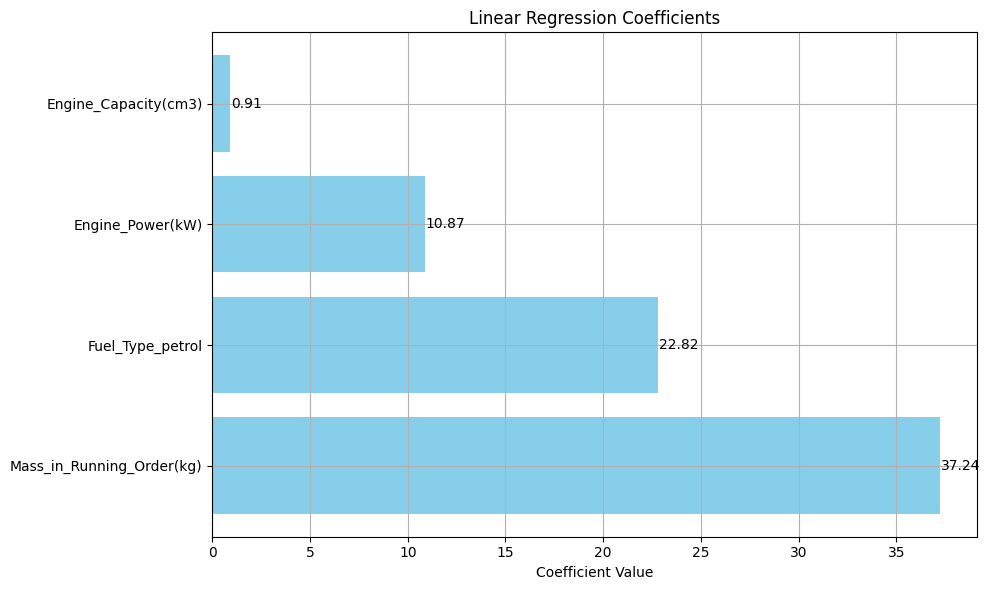

In [18]:
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model_scaled.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')

# Adding the coefficient values on the bars
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')

plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
train_test_diff = abs(train_r2_lr - test_r2_lr)
print(f"Train R²: {train_r2_lr:.3f}")
print(f"Test R²: {test_r2_lr:.3f}")
print(f"R² Difference: {train_test_diff:.3f}")

if train_test_diff > 0.05:
    print("Potential overfitting detected")
elif test_r2_lr > train_r2_lr:
    print("No overfitting - good generalization")
else:
    print("Good fit - minimal overfitting")

Train R²: 0.816
Test R²: 0.811
R² Difference: 0.005
Good fit - minimal overfitting


- R² Score: 0.81
    - This means 81% of the variance in CO₂ emissions is explained by the model. That’s a strong result for a linear model, especially considering the simplicity and interpretability.

- MSE: 373.25

    - The root of Mean Squared Error is 19.3, so the model predicts around 12% off the actual value, this MSE seems reasonable.

The model generalizes well and isn't heavily overfitting as the R2 difference is 0.005.

- Mass_in_Running_Order is the Strongest predictor. Heavier vehicles emit more CO₂
- The next strongest predictor is Fuel_Type_petrol. Petrol cars emit significantly more than diesel (since "petrol = 1")
- The weakest impact is the Engine_Capacity(cm3), which indicates that might be redundant with power or mass

#### Saving the Model for Streamlit

In [20]:
import joblib

# Save the scaler
joblib.dump(scaler_lin, '../models/scaler_lin.pkl')

# Save the model
joblib.dump(lr_model_scaled, '../models/linear_regression_model.pkl')

NameError: name 'scaler_lin' is not defined

## Model 2 - Lasso model

In [19]:
from sklearn.linear_model import Lasso

In [20]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
scaler_lasso = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler_lasso.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler_lasso.transform(X_test[features_to_scale])


In [23]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


Lasso Test MSE: 373.32
Lasso Test MAE: 12.02
Lasso Test RMSE: 19.32
Lasso Test R²: 0.811


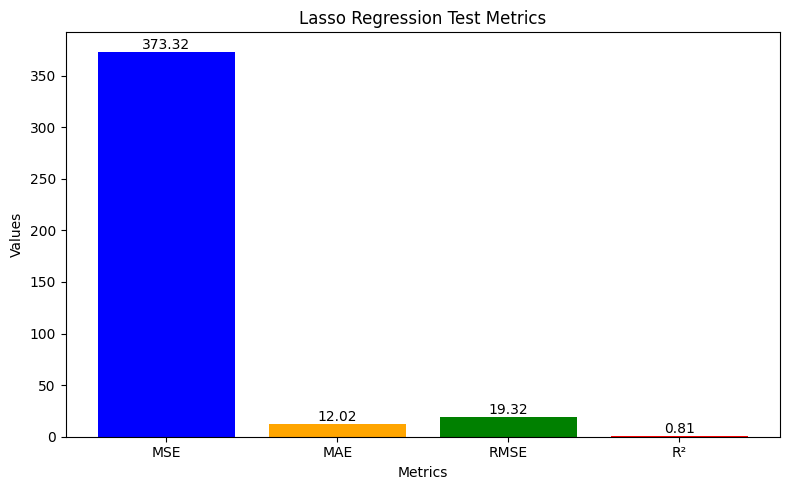

In [24]:
y_pred = lasso_model.predict(X_test_scaled)

# Calculate MSE, MAE, RMSE, and R²
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mrse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print Evaluation Metrics
print(f"Lasso Test MSE: {mse:.2f}")
print(f"Lasso Test MAE: {mae:.2f}")
print(f"Lasso Test RMSE: {mrse:.2f}")
print(f"Lasso Test R²: {r2:.3f}")

# Prepare data for the graph
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, mrse, r2]

# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])

# Add the values on top of the bars
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Lasso Regression Test Metrics')

plt.tight_layout()
plt.show()

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    36.971072
3           Fuel_Type_petrol    21.985693
2           Engine_Power(kW)    11.147560
1       Engine_Capacity(cm3)     0.661750


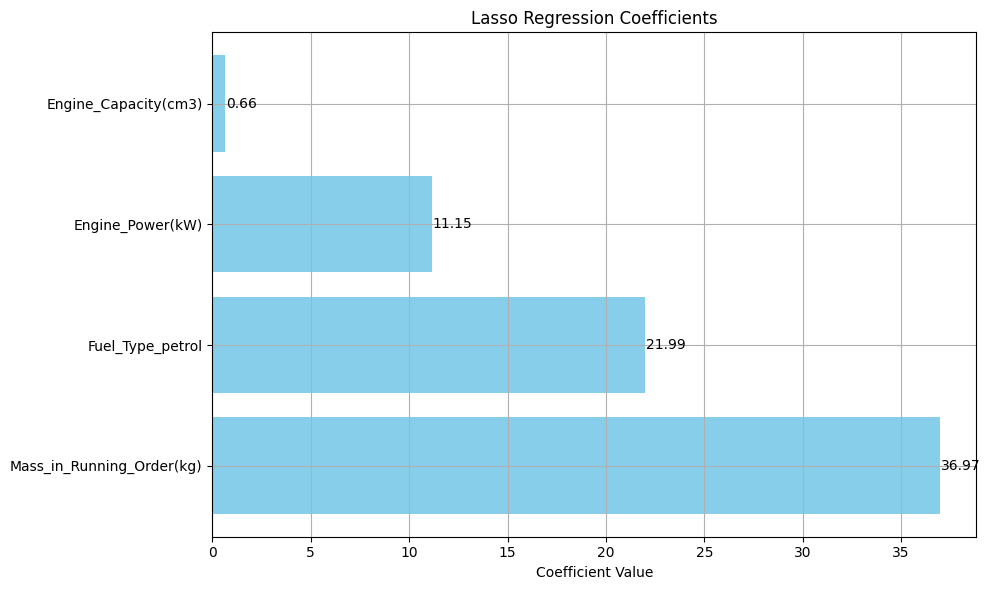

In [25]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')

# Adding the coefficient values on the bars
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')

plt.xlabel('Coefficient Value')
plt.title('Lasso Regression Coefficients')
plt.grid(True)
plt.tight_layout()
plt.show()

Best alpha: 0.0012648552168552957
Test MSE: 373.2502988016058
Lasso Test RMSE: 19.32
Test R²: 0.8111775248805912


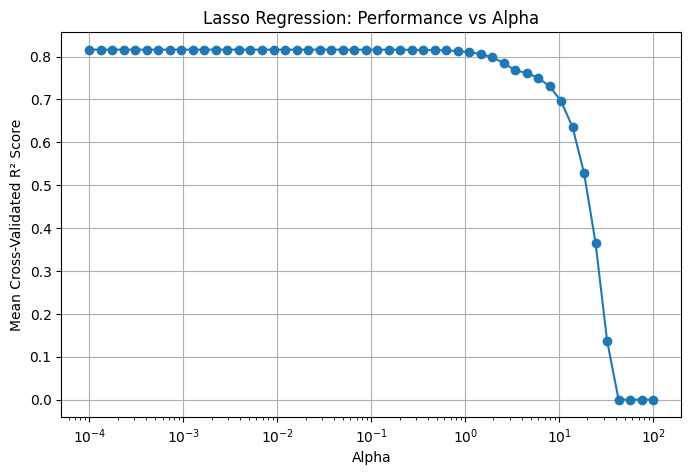

In [26]:
from sklearn.model_selection import train_test_split, GridSearchCV

# Define Lasso model and alpha grid
lasso = Lasso(max_iter=10000)
alphas = {'alpha': np.logspace(-4, 2, 50)}  

# Grid search for best alpha
grid = GridSearchCV(lasso, alphas, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

# Best model evaluation
best_lasso = grid.best_estimator_
y_pred = best_lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mrse = np.sqrt(mse)

print("Best alpha:", grid.best_params_['alpha'])
print("Test MSE:", mse)
print(f"Lasso Test RMSE: {mrse:.2f}")
print("Test R²:", r2)

# Plot alpha vs CV R²
plt.figure(figsize=(8, 5))
plt.semilogx(alphas['alpha'], grid.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Alpha')
plt.ylabel('Mean Cross-Validated R² Score')
plt.title('Lasso Regression: Performance vs Alpha')
plt.grid(True)
plt.show()



The results are very similar to Linear Model above.

#### Saving the model for Streamlit

In [27]:
# Save the scaler
joblib.dump(scaler_lasso, '../models/scaler_lasso.pkl')

# Save the model
joblib.dump(lasso_model, '../models/lasso_model.pkl')

['../models/lasso_model.pkl']

## Model 3 - RandomForestRegressor 

RandomForestRegressor does not require scaling or normalization

Test MSE: 131.69
Test MAE: 4.96
Test RMSE: 11.48
Test R² Score: 0.933


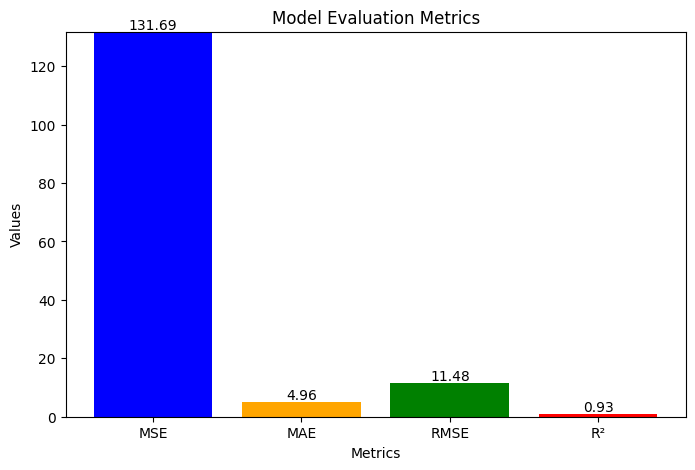

In [28]:
from sklearn.ensemble import RandomForestRegressor

X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mrse = np.sqrt(mse)  

r2 = r2_score(y_test, y_pred)


print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {mrse:.2f}")
print(f"Test R² Score: {r2:.3f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, mrse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')


plt.ylim([0, max(values) + 0.1])


for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')


plt.show()

R² score of 0.93 is very good, because it means that the model can explain 93% of the data variance. 
The MSE of 131.69, so the RMSE is 11.48 g/km, this means that on average, your model's prediction is  around 11.5 g/km or 6% off from the true CO₂ emission value. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 62.32
Test MSE: 131.69
Train MAE: 3.97
Test MAE: 4.96
Train RMSE: 7.89
Test RMSE: 11.48
Train R² Score: 0.969
Test R² Score: 0.933


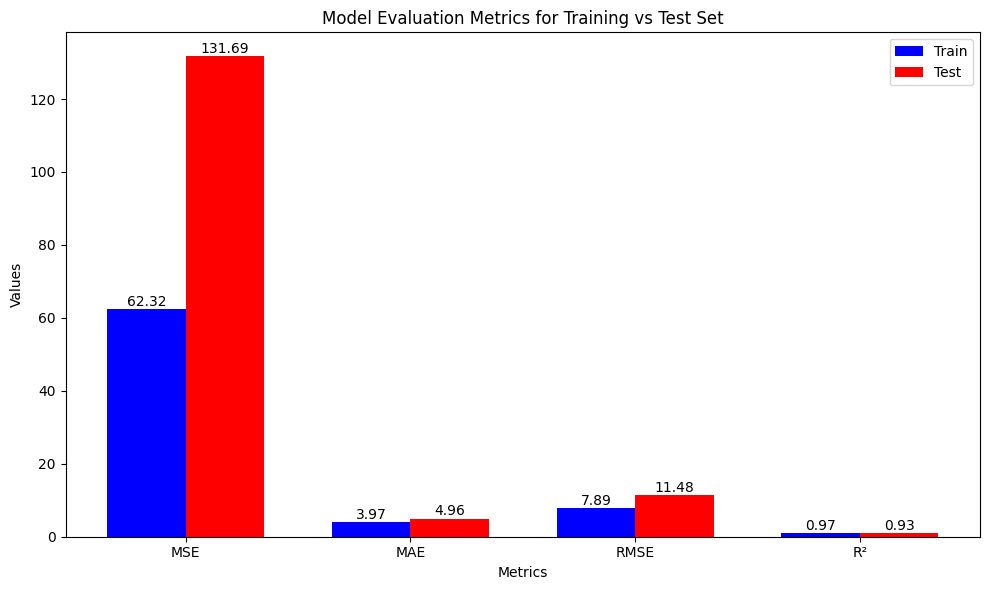

In [29]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mrse = np.sqrt(train_mse)
test_mrse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]


bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')


plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()


for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.97 shows it explains 97% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.93, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

In oder to get a higher confidence in our results, we perform a cross-validation

In [30]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.3f}")

Cross-validated R² scores: [0.93869596 0.93664242 0.92828702 0.92932125 0.9337159 ]
Mean CV R² score: 0.933


- Consistent performance: Scores range from 0.928 to 0.939. This suggests model's performance is very good across different data splits.

- No severe overfitting:
    Test R² (0.93), train R² (0.97), and CV R² (0.93) are all close. The R² difference (0.04) is acceptable and suggests minimal overfitting.

- Model status: The overall performance of the model is strong. The model is well fitted and generalizes well. 

#### Hyperparameter Tuning

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2],
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validated R² score: 0.9351930979480934


In [32]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

# Best estimator
best_model_Random_Forest = grid_search.best_estimator_

# Predictions
y_train_pred = best_model_Random_Forest.predict(X_train)
y_test_pred = best_model_Random_Forest.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nFine-tuned Model Performance:")
print(f"Train MSE: {train_mse:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Train MAE: {train_mae:.3f}")
print(f"Train R²: {train_r2:.3f}")

print(f"\nTest MSE: {test_mse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R²: {test_r2:.3f}")


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validated R² score: 0.9351930979480934

Fine-tuned Model Performance:
Train MSE: 75.933
Train RMSE: 8.714
Train MAE: 4.353
Train R²: 0.962

Test MSE: 128.456
Test RMSE: 11.334
Test MAE: 5.053
Test R²: 0.935


Model Comparison and Evaluation

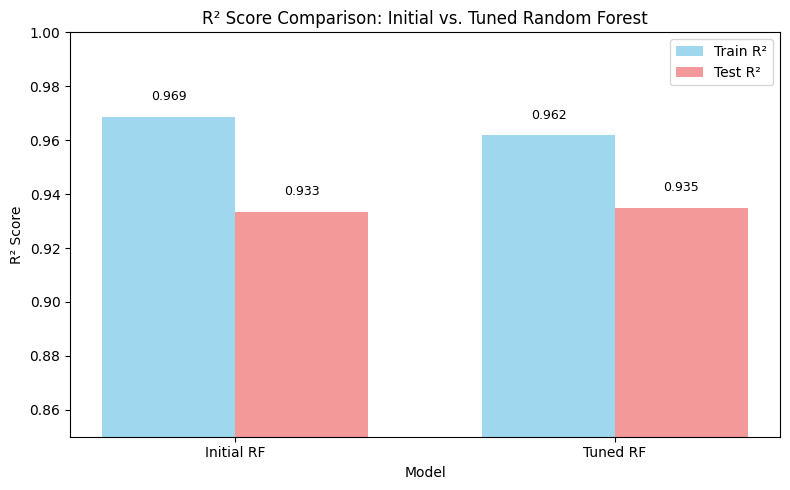

In [33]:
initial_train_r2 = r2_score(y_train, rf_model.predict(X_train))
initial_test_r2 = r2_score(y_test, rf_model.predict(X_test))
tuned_train_r2 = r2_score(y_train, best_model_Random_Forest.predict(X_train))
tuned_test_r2 = r2_score(y_test, best_model_Random_Forest.predict(X_test))

comparison_df = pd.DataFrame({
    'Model': ['Initial RF', 'Tuned RF'],
    'Train_R2': [initial_train_r2, tuned_train_r2],
    'Test_R2': [initial_test_r2, tuned_test_r2]
})

fig, axes = plt.subplots(1, 1, figsize=(8, 5))
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

axes.bar(x - width/2, train_r2_vals, width, label='Train R²', alpha=0.8, color='skyblue')
axes.bar(x + width/2, test_r2_vals, width, label='Test R²', alpha=0.8, color='lightcoral')

axes.set_xlabel('Model')
axes.set_ylabel('R² Score')
axes.set_title('R² Score Comparison: Initial vs. Tuned Random Forest')
axes.set_xticks(x)
axes.set_xticklabels(models_names)
axes.legend()
axes.set_ylim([0.85, 1.0])

for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes.text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
              ha='center', va='bottom', fontsize=9)
    axes.text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



We observe slight improvement with hyperparameter optimization on CV R2 scores. We didn't expect more as it is already performing good

#### Saving the model for Streamlit

In [34]:
# Save the model
joblib.dump(best_model_Random_Forest, '../models/best_model_Random_Forest.pkl')

['../models/best_model_Random_Forest.pkl']

## Model 4 - XGBoost model

XGBoost does not require scaling or normalization

In [35]:
from xgboost import XGBRegressor   

In [36]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Basic Model Performance:
MSE: 154.45
RMSE: 12.43
R² Score: 0.922
MAE: 6.14


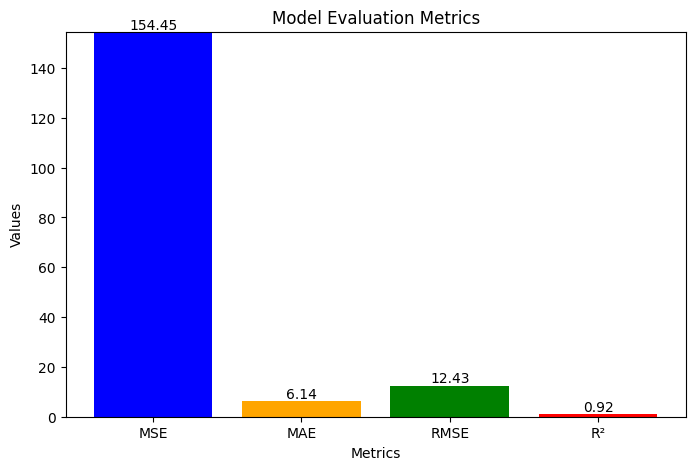

In [38]:
xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

xgb_basic.fit(X_train, y_train)
y_pred_basic = xgb_basic.predict(X_test)

# Basic model evaluation
mse_basic = mean_squared_error(y_test, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_test, y_pred_basic))
r2_basic = r2_score(y_test, y_pred_basic)
mae_basic = mean_absolute_error(y_test, y_pred_basic)


print(f"Basic Model Performance:")
print(f"MSE: {mse_basic:.2f}")
print(f"RMSE: {rmse_basic:.2f}")
print(f"R² Score: {r2_basic:.3f}")
print(f"MAE: {mae_basic:.2f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse_basic, mae_basic, rmse_basic, r2_basic]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

plt.ylim([0, max(values) + 0.1])

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

plt.show()



R² score of 0.92 is very good, because it means that the model can explain 92% of the data variance. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 105.57
Test MSE: 154.45
Train MAE: 5.71
Test MAE: 6.14
Train RMSE: 10.27
Test RMSE: 12.43
Train R² Score: 0.947
Test R² Score: 0.922


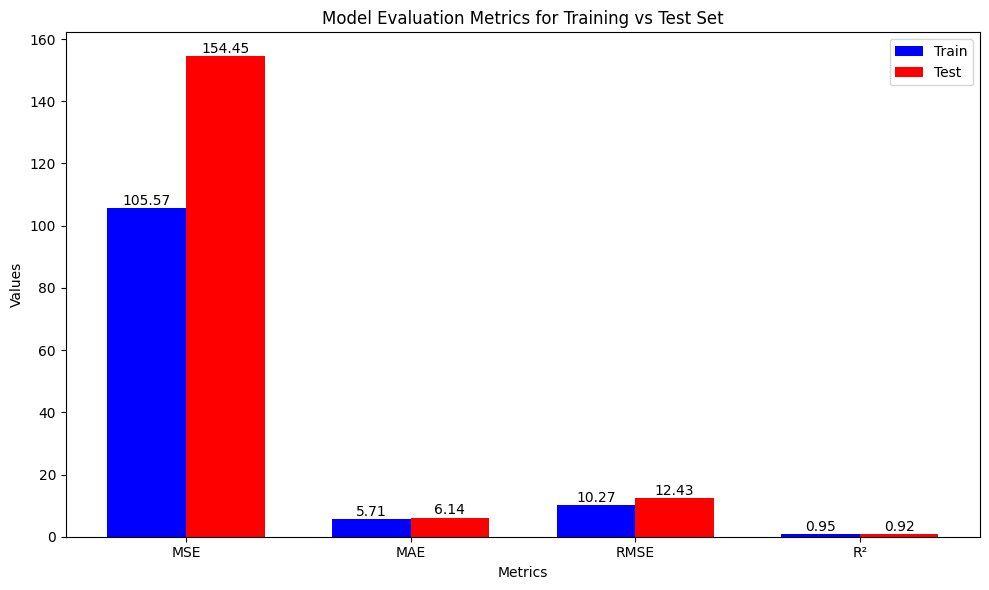

In [39]:
# Predictions for Training and Test Set
y_train_pred = xgb_basic.predict(X_train)
y_test_pred = xgb_basic.predict(X_test)

# Calculate MSE, MAE, RMSE, and R² for Training and Test Set
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mrse = np.sqrt(train_mse)
test_mrse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print Evaluation Metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# Create a graph to compare metrics for Training vs Test set
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Display the values on top of the bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.95 shows it explains 95% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.92, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

- The model captures the underlying relationship between vehicle characteristics and CO2 emissions very well
- Performance is consistent between training and test sets (no severe overfitting)
- Error levels are practically acceptable for most applications

However, The mild overfitting suggests hyperparameter tuning could help

In [40]:
cv_scores = cross_val_score(xgb_basic, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.3f}")

Cross-validated R² scores: [0.93313169 0.93874192 0.92551714 0.925372   0.92638141]
Mean CV R² score: 0.930


We see very similar pattern as Random Forest Model results. 

The overall performance of the model is strong. The model is well fitted and generalizes well. 

#### Hyperparameter Tuning

In [42]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 0.9, 1.0],
    'reg_alpha': [0.1, 1, 10],
    'reg_lambda': [1, 10, 100],
    'colsample_bytree': [0.7, 0.8, 0.9]
}


xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

grid_search = GridSearchCV(
    estimator=xgb_basic,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)


Fitting 5 folds for each of 1458 candidates, totalling 7290 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 200, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 1.0}
Best cross-validated R² score: 0.9338969111442565


In [43]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

best_model_XGBoost = grid_search.best_estimator_

y_train_pred = best_model_XGBoost.predict(X_train)
y_test_pred = best_model_XGBoost.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nFine-tuned Model Performance:")
print(f"Train MSE: {train_mse:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Train MAE: {train_mae:.3f}")
print(f"Train R²: {train_r2:.3f}")

print(f"\nTest MSE: {test_mse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R²: {test_r2:.3f}")

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 200, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 1.0}
Best cross-validated R² score: 0.9338969111442565

Fine-tuned Model Performance:
Train MSE: 90.500
Train RMSE: 9.513
Train MAE: 5.016
Train R²: 0.954

Test MSE: 144.963
Test RMSE: 12.040
Test MAE: 5.590
Test R²: 0.927


Model Comparison and Evaluation

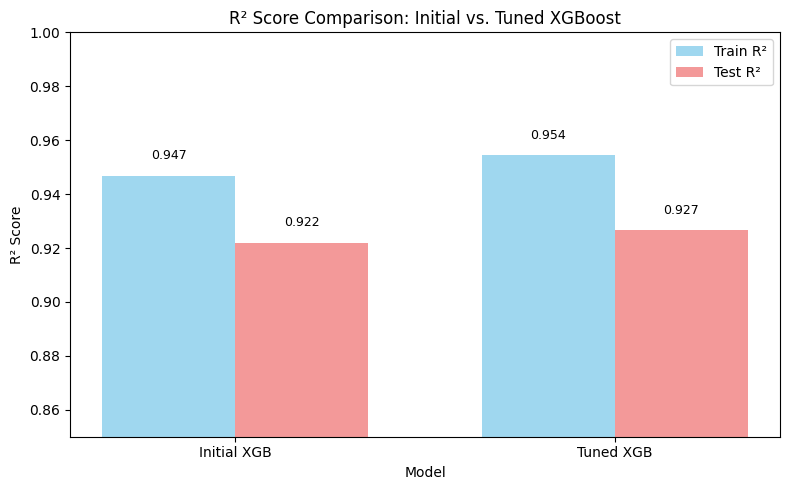

In [44]:

xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

xgb_basic.fit(X_train, y_train)
y_pred_basic = xgb_basic.predict(X_test)

initial_train_r2 = r2_score(y_train, xgb_basic.predict(X_train))
initial_test_r2 = r2_score(y_test, xgb_basic.predict(X_test))
tuned_train_r2 = r2_score(y_train, best_model_XGBoost.predict(X_train))
tuned_test_r2 = r2_score(y_test, best_model_XGBoost.predict(X_test))

comparison_df = pd.DataFrame({
    'Model': ['Initial XGB', 'Tuned XGB'],
    'Train_R2': [initial_train_r2, tuned_train_r2],
    'Test_R2': [initial_test_r2, tuned_test_r2]
})

fig, axes = plt.subplots(1, 1, figsize=(8, 5))
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

axes.bar(x - width/2, train_r2_vals, width, label='Train R²', alpha=0.8, color='skyblue')
axes.bar(x + width/2, test_r2_vals, width, label='Test R²', alpha=0.8, color='lightcoral')


axes.set_xlabel('Model')
axes.set_ylabel('R² Score')
axes.set_title('R² Score Comparison: Initial vs. Tuned XGBoost')
axes.set_xticks(x)
axes.set_xticklabels(models_names)
axes.legend()
axes.set_ylim([0.85, 1.0])

for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes.text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
              ha='center', va='bottom', fontsize=9)
    axes.text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

We have seen a slight overfitting reduction after hyperparameter tuning, but that also costs us some performance degradation. 


#### Saving the Model for Streamlit

In [45]:
# Save the model
joblib.dump(best_model_XGBoost, '../models/best_model_XGBoost.pkl')

['../models/best_model_XGBoost.pkl']

## Model 5 - Deeplearning model

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_dl = StandardScaler()
X_train_scaled = scaler_dl.fit_transform(X_train)
X_test_scaled = scaler_dl.transform(X_test)


dl_model = Sequential()
# Input layer
dl_model.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

# Hidden layers
dl_model.add(Dense(128, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(64, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(32, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dropout(0.1))

# Output layer
dl_model.add(Dense(1, activation='linear')) 

dl_model.compile(optimizer=Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999), loss='mse', metrics=['mae'])

print("Model Architecture:")
dl_model.summary()

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.8,
    patience=15,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

history = dl_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

y_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.3f}")


Model Architecture:


/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,977 (183.50 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 25840.0957 - mae: 154.8586 - val_loss: 4664.2544 - val_mae: 48.7520 - learning_rate: 5.0000e-04
Epoch 2/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3841.5427 - mae: 49.5160 - val_loss: 598.2511 - val_mae: 15.8885 - learning_rate: 5.0000e-04
Epoch 3/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1790.0050 - mae: 32.4466 - val_loss: 508.8887 - val_mae: 14.8296 - learning_rate: 5.0000e-04
Epoch 4/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1554.8483 - mae: 30.1062 - val_loss: 443.8502 - val_mae: 13.6325 - learning_rate: 5.0000e-04
Epoch 5/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1430.7059 - mae: 28.9680 - val_loss: 365.2991 - val_mae: 12.0136 - learning_rate: 5.0000e-04
Epoch 6/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1361.2089 - mae: 28.3622 - val_loss: 368.1648 - val_mae: 12.4417 - learning_rate: 5.0000e-04
Epoch 7/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1287.5693 - 

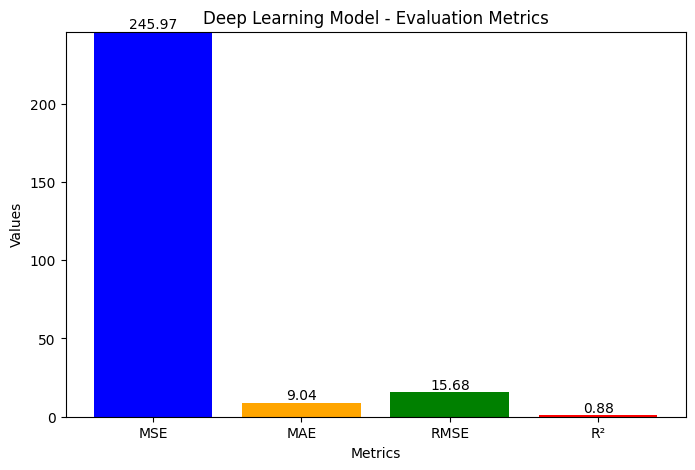

In [ ]:
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, rmse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Deep Learning Model - Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

plt.ylim([0, max(values) + 0.1])

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

plt.show()

Train MSE: 241.98
Test MSE: 245.97
Train MAE: 8.99
Test MAE: 9.04
Train RMSE: 15.56
Test RMSE: 15.68
Train R² Score: 0.878
Test R² Score: 0.876


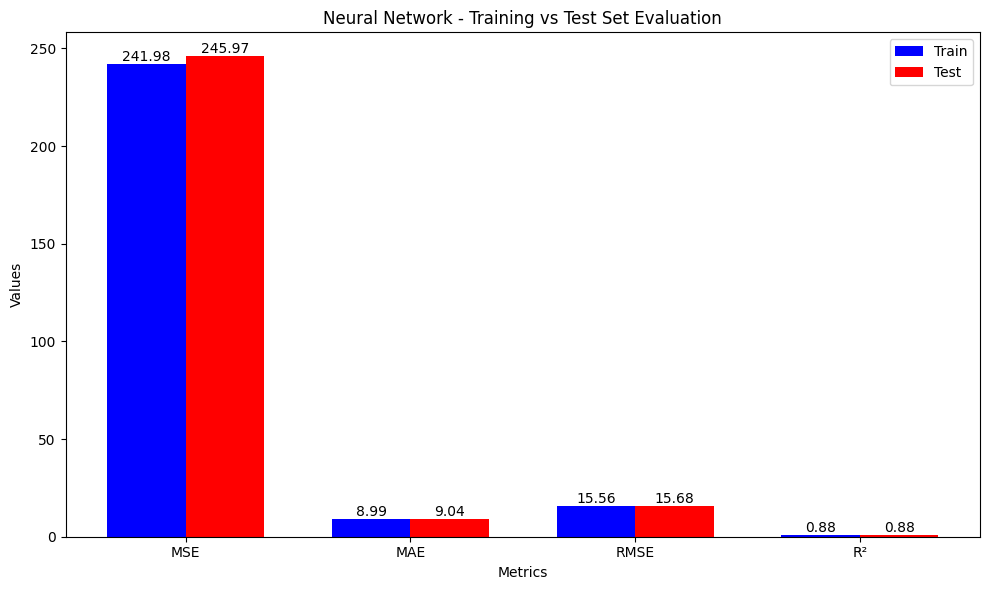

In [ ]:

y_train_pred = dl_model.predict(X_train_scaled, verbose=0).flatten()
y_test_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_rmse, train_r2]
test_values = [test_mse, test_mae, test_rmse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Neural Network - Training vs Test Set Evaluation')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()



We don't see much difference between training & validation results for MSE, MAE, and RMSE, indicating the model generalizes well, while the R² score of 0.87 shows it explains 87% of the variance in the training set.

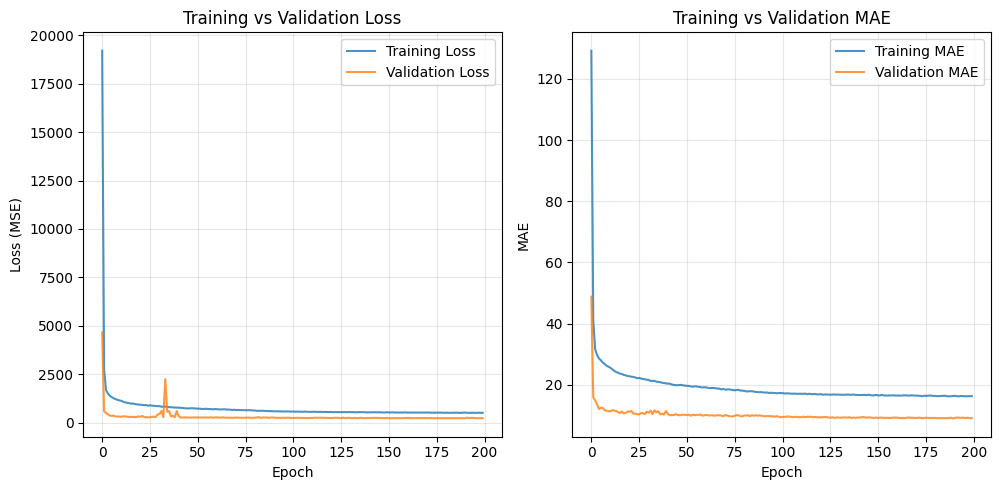

In [ ]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss', alpha=0.8)
plt.plot(history.history['val_loss'], label='Validation Loss', alpha=0.8)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE', alpha=0.8)
plt.plot(history.history['val_mae'], label='Validation MAE', alpha=0.8)
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

if 'lr' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['lr'])
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Feature Importance Analysis

Feature Importance Rankings:
Mass_in_Running_Order(kg): 1.5643
Engine_Capacity(cm3): 0.5543
Fuel_Type_petrol: 0.3297
Engine_Power(kW): 0.1525


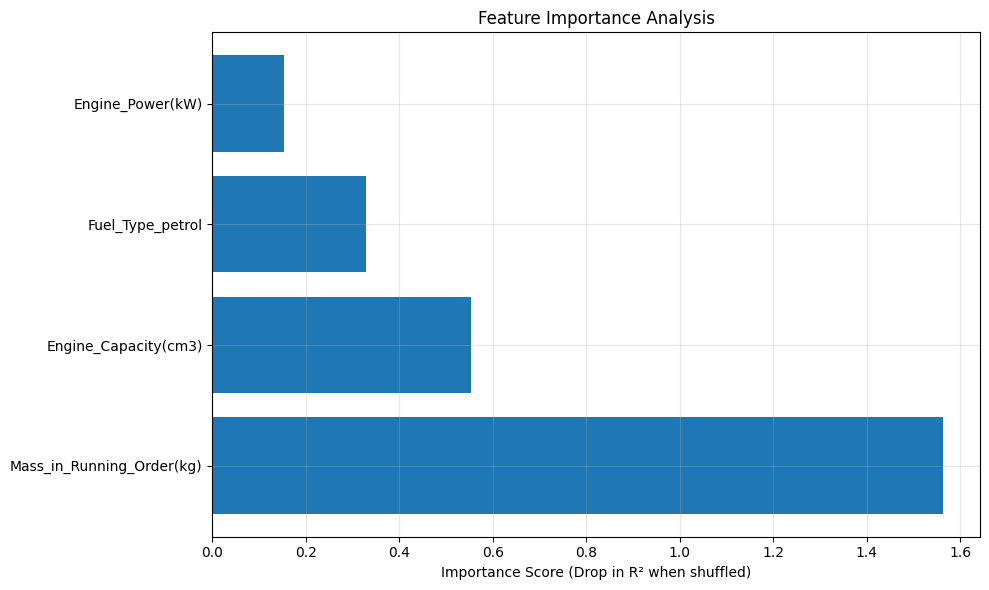

In [47]:

feature_names = X.columns.tolist()
baseline_score = r2_score(y_test, y_pred)
feature_importance = []

for i, feature in enumerate(feature_names):
    # Create a copy and shuffle one feature
    X_test_permuted = X_test_scaled.copy()
    np.random.shuffle(X_test_permuted[:, i])
    
    # Get predictions with shuffled feature
    y_pred_permuted = dl_model.predict(X_test_permuted, verbose=0).flatten()
    permuted_score = r2_score(y_test, y_pred_permuted)
    
    # Importance = drop in performance
    importance = baseline_score - permuted_score
    feature_importance.append(importance)

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings:")
for idx, row in feature_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_df)), feature_df['Importance'])
plt.yticks(range(len(feature_df)), feature_df['Feature'])
plt.xlabel('Importance Score (Drop in R² when shuffled)')
plt.title('Feature Importance Analysis')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Saving the model for Streamlit

In [48]:
# Save the scaler
joblib.dump(scaler_dl, '../models/scaler_dl.pkl')

# Save the model
joblib.dump(dl_model, '../models/dl_model.pkl')

['../models/dl_model.pkl']

## <span style="color:orange">Model Comparison & Conclusions</span>

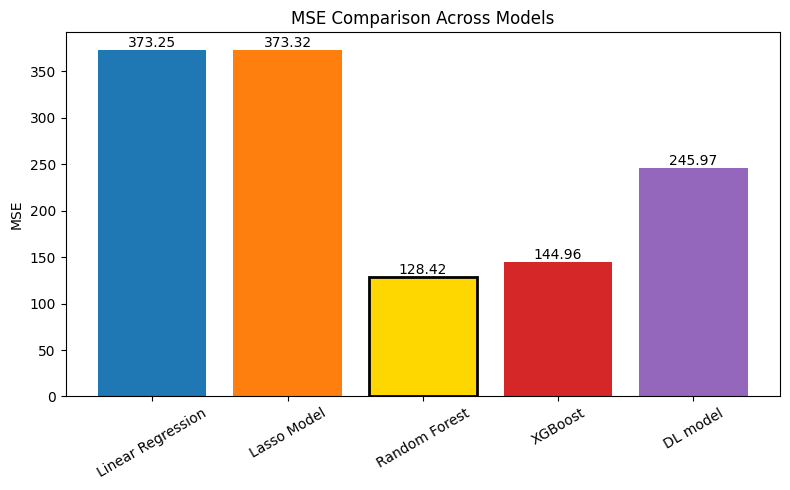

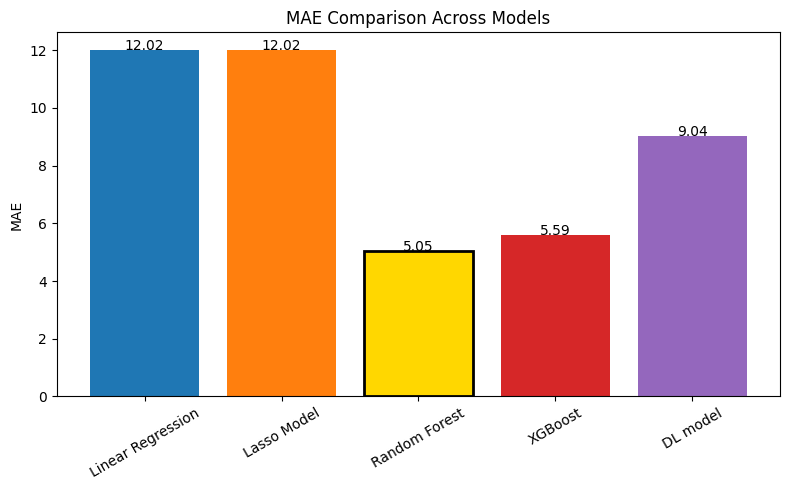

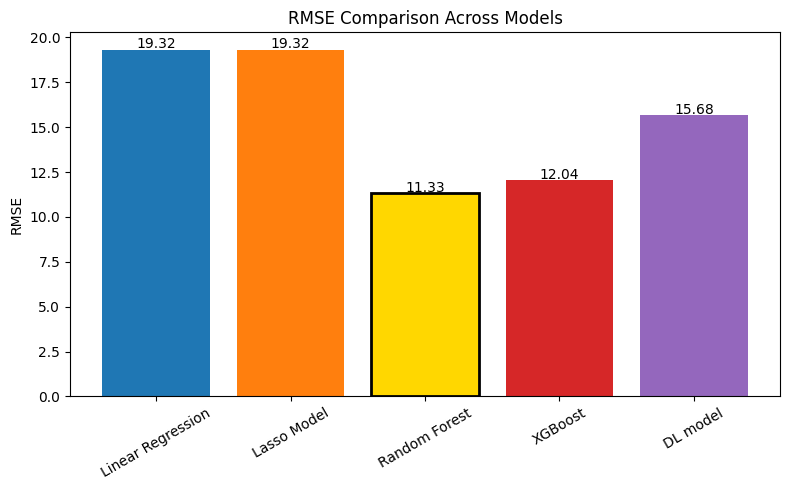

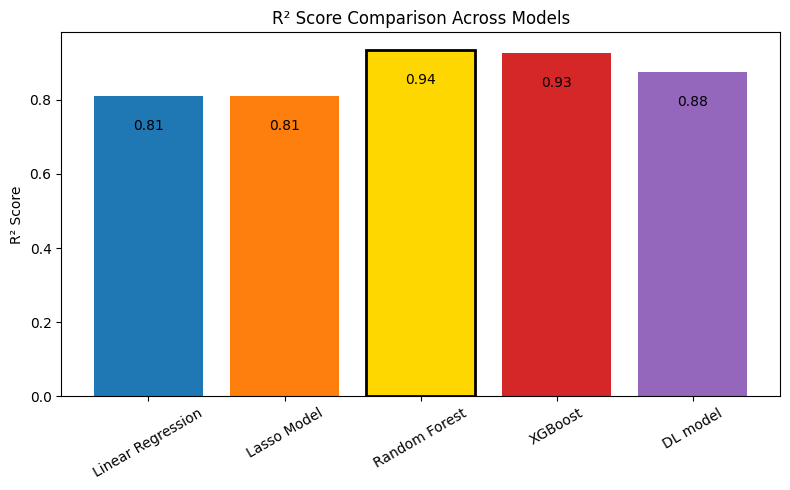

In [ ]:
data = {
    "Metric": ["MSE", "MAE", "RMSE", "R² Score"],
    "Linear Regression": [373.25, 12.02, 19.32, 0.811],
    "Lasso Model": [373.32, 12.02, 19.32, 0.811],
    "Random Forest": [128.42, 5.05, 11.33, 0.935],
    "XGBoost": [144.96, 5.59, 12.04, 0.927],
    "DL model": [245.97, 9.04, 15.68, 0.876],
}


df = pd.DataFrame(data)
df.set_index("Metric", inplace=True)
models = df.columns

model_colors = {
    "Linear Regression":'#1f77b4',
    "Lasso Model": '#ff7f0e',
    "Random Forest": '#2ca02c',
    "XGBoost":  '#d62728',
    "DL model": '#9467bd'
}

for metric in df.index:
    plt.figure(figsize=(8, 5))
    
    values = df.loc[metric]
    bars = plt.bar(models, values, color=[model_colors[model] for model in models])
    
    if metric != "R² Score":
        best_model = values.idxmin()
    else:
        best_model = values.idxmax()
    
    best_idx = models.get_loc(best_model)
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval - 0.1, f"{yval:.2f}", ha='center', va='bottom')

    plt.title(f'{metric} Comparison Across Models')
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()



When we compare the all 5 models above then we see that Random Forest model's performance is better than XGBoost and others. Therefore, we will proceed next steps with Random Forest model


| Metric       | Linear Regression | Lasso Model | Random Forest | XGBoost | DL model | Winner              |
|--------------|-------------------|-------------|---------------|---------|----------|---------------------|
| **MSE**      | 373.25            | 373.32      | **128.42**    | 144.96  | 254.97   | 🏆**Random Forest** |
| **MAE**      | 12.02             | 12.02       | **5.05**      | 5.59    | 9.04     | 🏆**Random Forest** |
| **RMSE**     | 19.32             | 19.32       | **11.33**     | 12.04   | 15.68    | 🏆**Random Forest** |
| **R² Score** | 0.811             | 0.811       | **0.935**     | 0.927   | 0.876    | 🏆**Random Forest** |


Random Forest shows:

- 5.9% lower prediction error (RMSE improvement) than the second best model (XGBoost)
- 0.8% higher variance explained (R² improvement) than the second best model (XGBoost)

## SHAP Values

In [45]:
import shap

Now we want to look at more specific values.

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_74623/2075006247.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


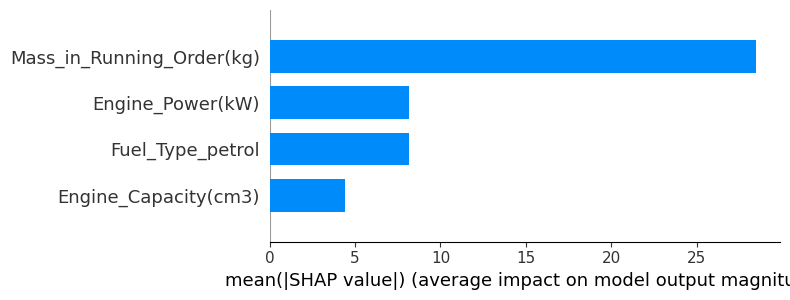

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_74623/2075006247.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


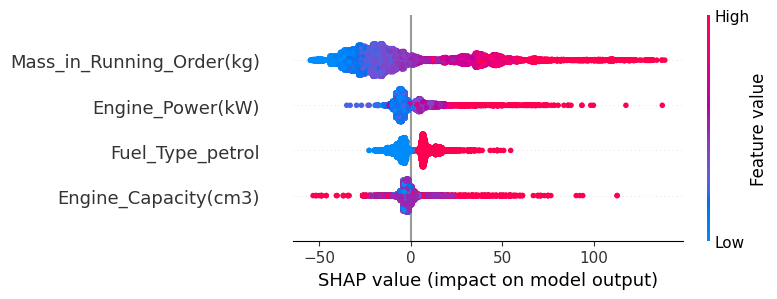

In [46]:
model = best_model_Random_Forest

# Create a SHAP explainer for your Random Forest model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for your test data
shap_values = explainer.shap_values(X_test)

# Plot a summary of feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

# Plot a detailed summary (shows feature impact direction)
shap.summary_plot(shap_values, X_test)
plt.show()

Saving the graph for streamlit

In [25]:
import joblib
joblib.dump(X_test, "../data/X_test.pkl")

['../data/X_test.pkl']

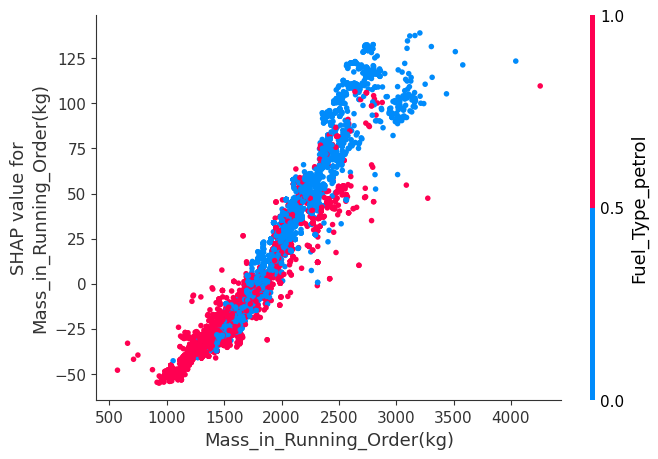

In [47]:
shap.dependence_plot("Mass_in_Running_Order(kg)", shap_values, X_test, interaction_index= "Fuel_Type_petrol")

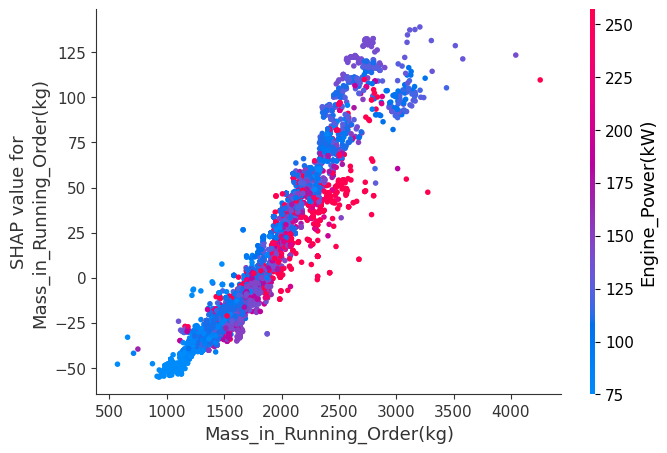

In [48]:
shap.dependence_plot("Mass_in_Running_Order(kg)", shap_values, X_test, interaction_index= "Engine_Power(kW)")

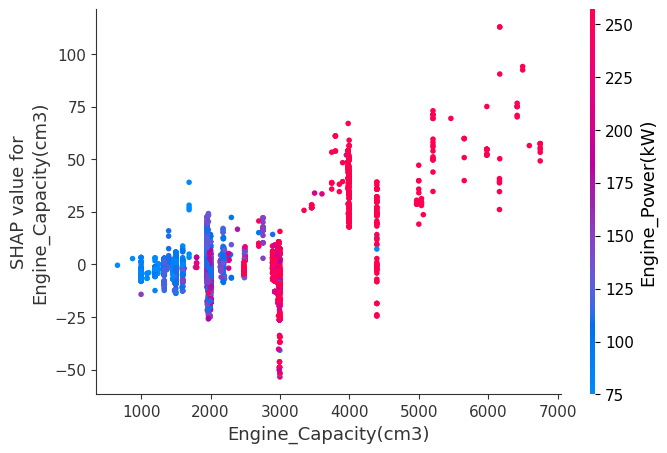

In [49]:
shap.dependence_plot("Engine_Capacity(cm3)", shap_values, X_test, interaction_index= "Engine_Power(kW)")


Sample 1


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
18355,1270,999,81,1


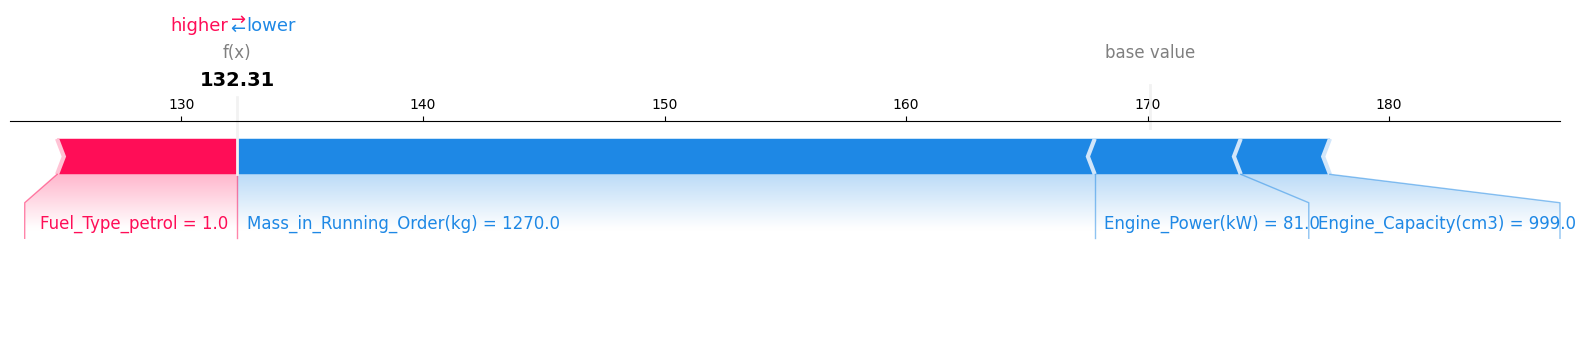


Sample 2


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
25638,1291,1199,81,1


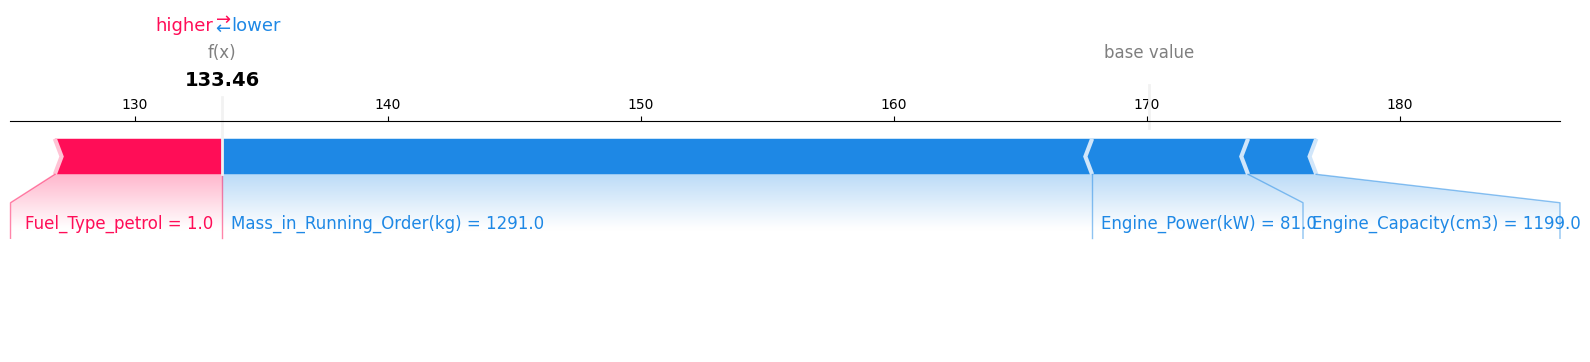


Sample 3


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
73623,3163,1968,130,0


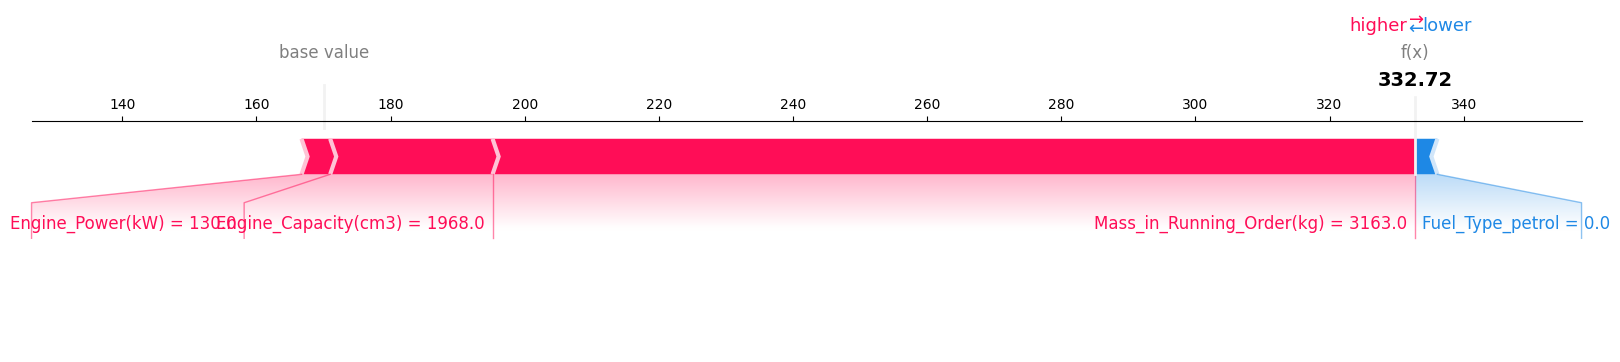


Sample 4


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
3186,1360,1498,110,1


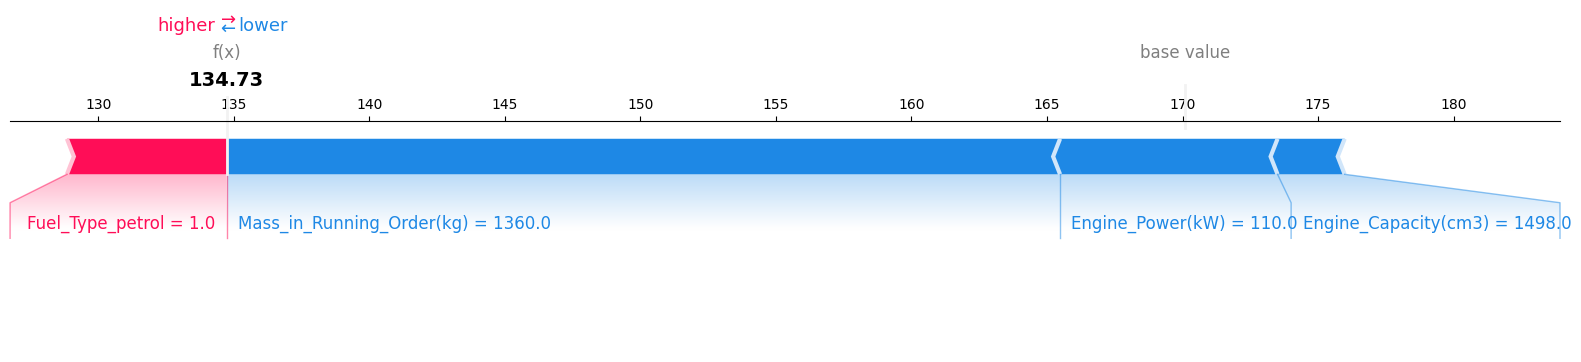


Sample 5


,Mass_in_Running_Order(kg),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
67227,1188,999,67,1


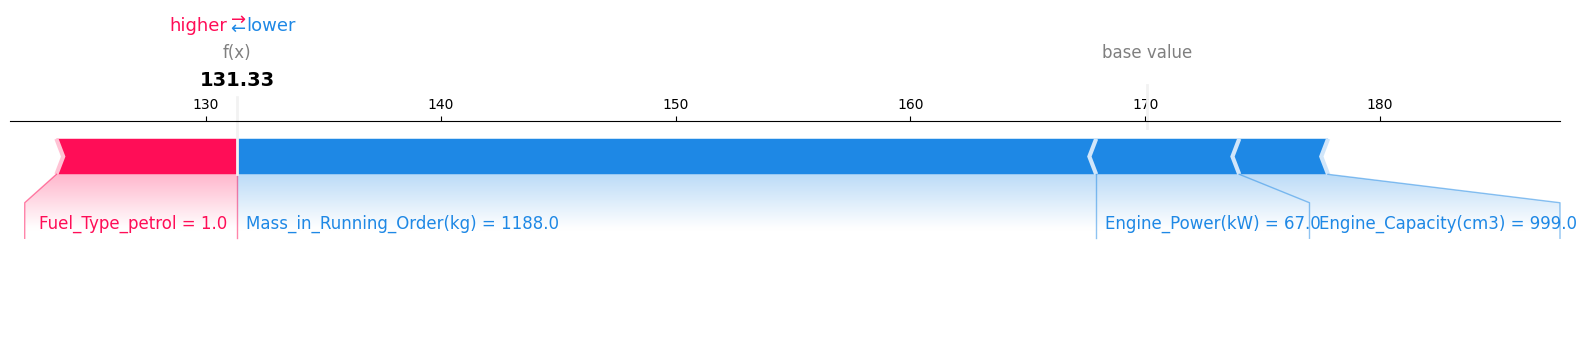

In [50]:
# 1. Randomly select 3–5 row positions (not indices) from the test set
n_samples = 5
random_positions = np.random.choice(len(X_test), size=n_samples, replace=False)
# 2. Subset by position
X_subset = X_test.iloc[random_positions]
shap_subset = shap_values[random_positions]
# 3. Loop through and plot
shap.initjs()
for i in range(n_samples):
    print(f"\nSample {i+1}")
    display(X_subset.iloc[i].to_frame().T)
    shap.force_plot(explainer.expected_value, shap_subset[i], X_subset.iloc[i], matplotlib=True)


=== Min CO₂ Emission (Predicted CO₂: 107.14 g/km) ===
Mass_in_Running_Order(kg): -42.64 (value: 1055)
Engine_Capacity(cm3): -2.39 (value: 1248)
Engine_Power(kW): -8.45 (value: 70)
Fuel_Type_petrol: -9.47 (value: 0)


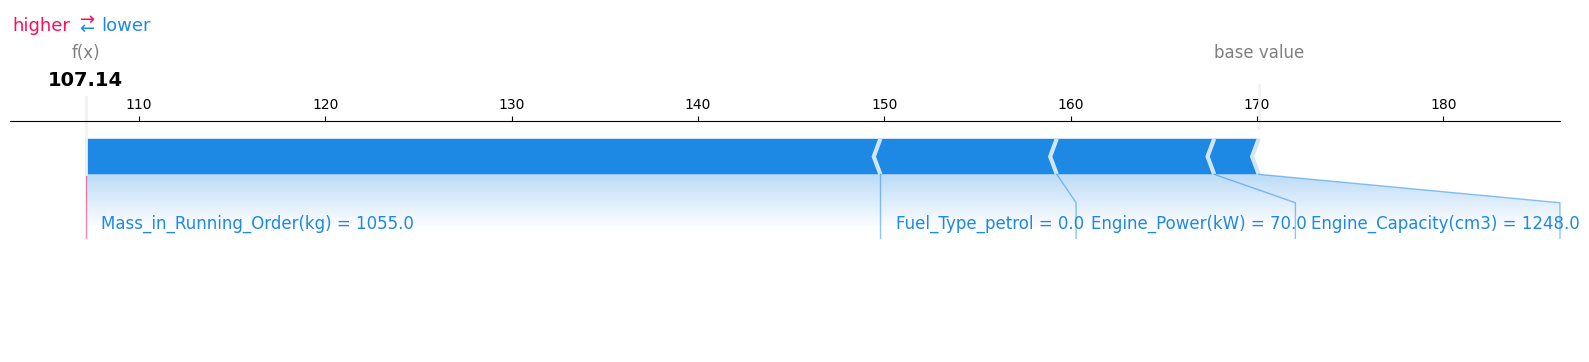


=== Median CO₂ Emission (Predicted CO₂: 157.15 g/km) ===
Mass_in_Running_Order(kg): -15.28 (value: 1673)
Engine_Capacity(cm3): -4.26 (value: 1968)
Engine_Power(kW): +9.75 (value: 147)
Fuel_Type_petrol: -3.15 (value: 0)


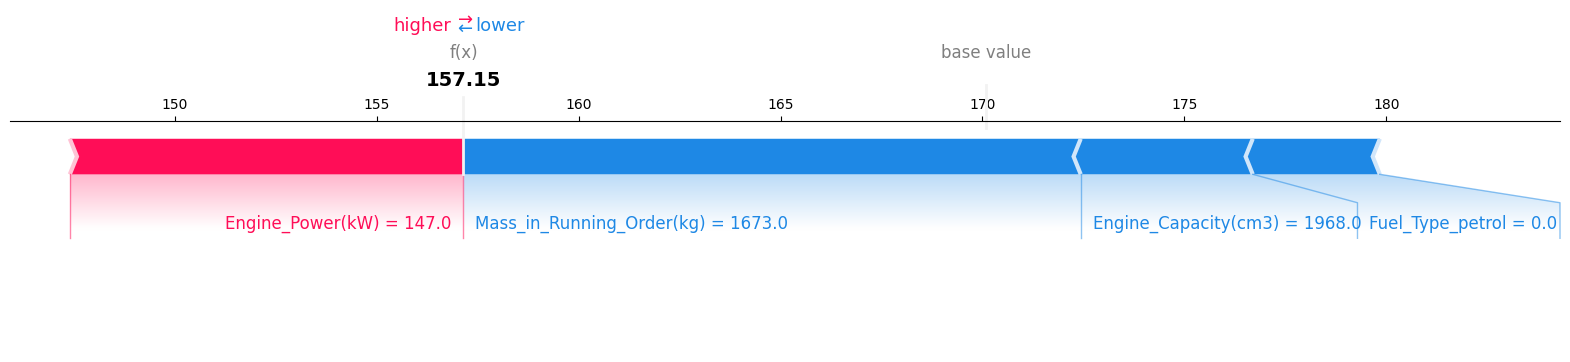


=== Mean CO₂ Emission (Predicted CO₂: 170.18 g/km) ===
Mass_in_Running_Order(kg): -11.07 (value: 1578)
Engine_Capacity(cm3): +2.19 (value: 1598)
Engine_Power(kW): -2.56 (value: 110)
Fuel_Type_petrol: +11.54 (value: 1)


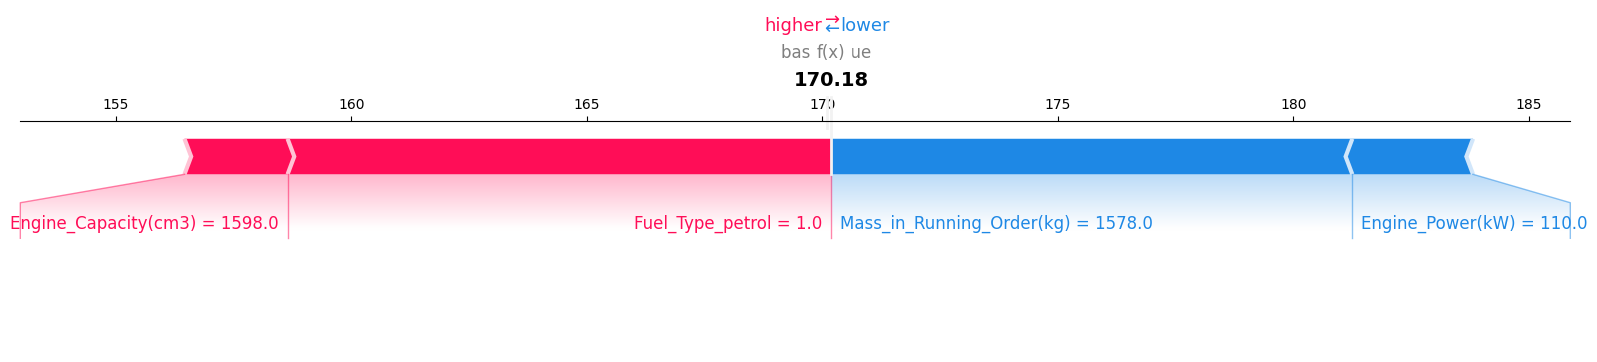


=== Max CO₂ Emission (Predicted CO₂: 420.24 g/km) ===
Mass_in_Running_Order(kg): +109.59 (value: 4255)
Engine_Capacity(cm3): +75.05 (value: 5980)
Engine_Power(kW): +38.22 (value: 450)
Fuel_Type_petrol: +27.28 (value: 1)


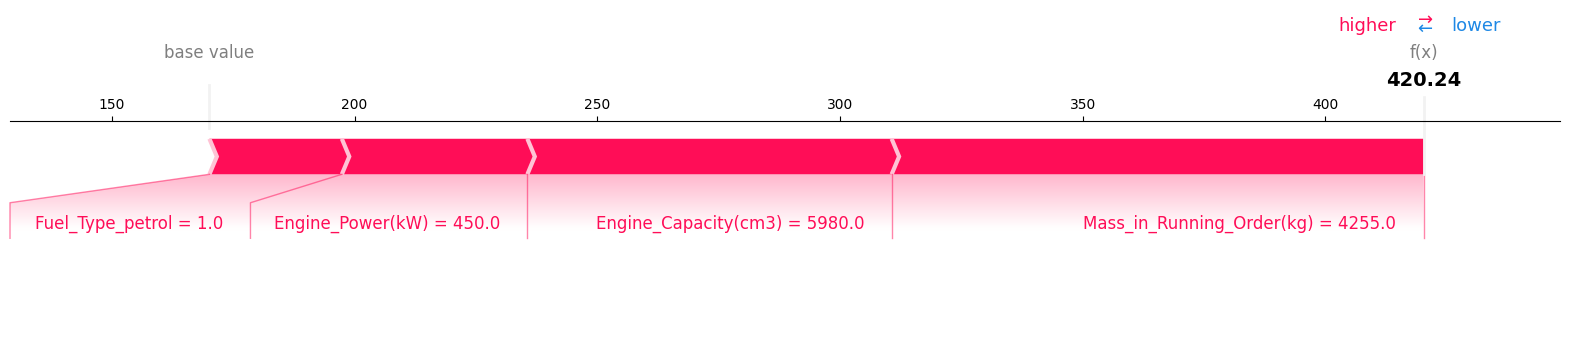

In [51]:
# Predict CO₂
y_test_pred = best_model_Random_Forest.predict(X_test)
# Indices
min_idx = np.argmin(y_test_pred)
max_idx = np.argmax(y_test_pred)
median_val = np.median(y_test_pred)
mean_val = np.mean(y_test_pred)
median_idx = (np.abs(y_test_pred - median_val)).argmin()
mean_idx = (np.abs(y_test_pred - mean_val)).argmin()
# Set up labels and indices
selected_indices = [min_idx, median_idx, mean_idx, max_idx]
labels = ["Min CO₂ Emission", "Median CO₂ Emission", "Mean CO₂ Emission", "Max CO₂ Emission"]
# SHAP init
shap.initjs()
# Print SHAP values and show force plots
for i, idx in enumerate(selected_indices):
    label = labels[i]
    shap_val = shap_values[idx]
    feature_row = X_test.iloc[idx]
    print(f"\n=== {label} (Predicted CO₂: {y_test_pred[idx]:.2f} g/km) ===")
    for feature_name, shap_score, feature_value in zip(X_test.columns, shap_val, feature_row):
        sign = "+" if shap_score >= 0 else "-"
        print(f"{feature_name}: {sign}{abs(shap_score):.2f} (value: {feature_value})")
    # Show SHAP force plot
    shap.force_plot(
        base_value=explainer.expected_value,
        shap_values=shap_val,
        features=feature_row,
        matplotlib=True
    )

The SHAP analysis of our Random Forest model illustrates how key vehicle features contribute to the prediction of CO₂ emissions, both in typical and extreme cases. Across the spectrum of predictions—from minimum to maximum emissions—the model consistently attributes the largest influence to engine capacity, engine power, and vehicle mass. Higher values in these features push emissions upward, while lower values reduce them. Fuel type also plays a moderating role, with petrol engines generally leading to higher predicted emissions than diesel. By analyzing representative samples—those near the minimum, maximum, median, and mean predictions—we can clearly observe how the model integrates feature interactions to arrive at its outputs. This reinforces the model's interpretability and confirms that its predictions align with domain expectations regarding emissions behavior. 